In [1]:
from reinvent_lm.generation import MoleculeGenerator
from reinvent_lm.filters import StructureFilter

molecule_generator = MoleculeGenerator(tokenizer_path="checkpoints/reinvent_property_guided_2/tokenizer.json", config_path="configs/train_reinvent.yaml", checkpoint_path="checkpoints/reinvent_property_guided_2/checkpoint_epoch_20.pt", device="cuda")

使用設備: cuda
載入配置檔案: configs/train_reinvent.yaml
載入 tokenizer: checkpoints/reinvent_property_guided_2/tokenizer.json
Tokenizer 已從 checkpoints/reinvent_property_guided_2/tokenizer.json 加載
詞彙表大小: 26
建立模型...
載入模型權重: checkpoints/reinvent_property_guided_2/checkpoint_epoch_20.pt
✓ MoleculeGenerator 初始化完成 (從檢查點載入)!



（22 個無效分子已略過，不會顯示在圖片中）


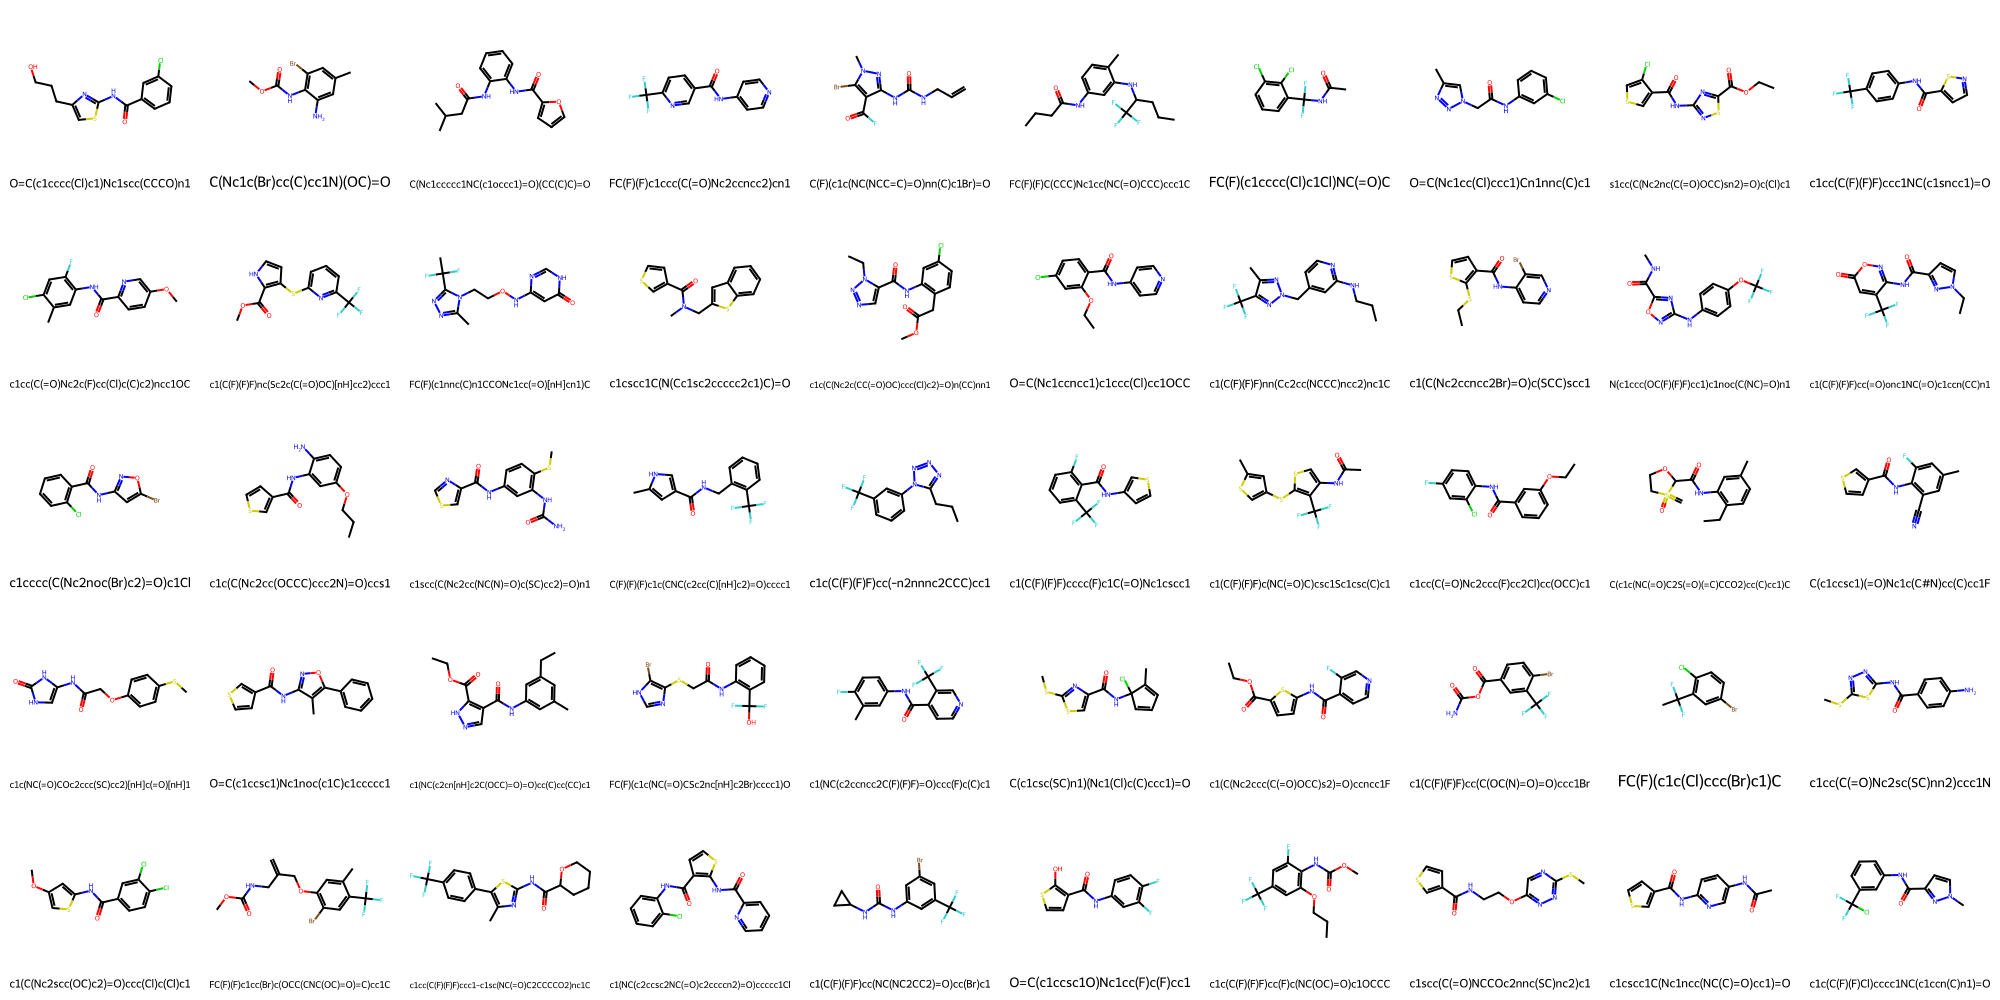

['O=C(c1cccc(Cl)c1)Nc1scc(CCCO)n1',
 'C(Nc1c(Br)cc(C)cc1N)(OC)=O',
 'C(Nc1ccccc1NC(c1occc1)=O)(CC(C)C)=O',
 'FC(F)(F)c1ccc(C(=O)Nc2ccncc2)cn1',
 'C(F)(c1c(NC(NCC=C)=O)nn(C)c1Br)=O',
 'FC(F)(F)C(CCC)Nc1cc(NC(=O)CCC)ccc1C',
 'FC(F)(c1cccc(Cl)c1Cl)NC(=O)C',
 'O=C(Nc1cc(Cl)ccc1)Cn1nnc(C)c1',
 's1cc(C(Nc2nc(C(=O)OCC)sn2)=O)c(Cl)c1',
 'c1cc(C(F)(F)F)ccc1NC(c1sncc1)=O',
 'c1cc(C(=O)Nc2c(F)cc(Cl)c(C)c2)ncc1OC',
 'FC(c1cccc(F)c1Br)NC(=O)OC)=O',
 'FC(F)(c1ccccc1)c1Nsc(NC(=O)CC#N)c1',
 'c1(C(F)(F)F)nc(Sc2c(C(=O)OC)[nH]cc2)ccc1',
 'FC(F)(c1nnc(C)n1CCONc1cc(=O)[nH]cn1)C',
 'c1cscc1C(N(Cc1sc2ccccc2c1)C)=O',
 'c1c(C(Nc2c(CC(=O)OC)ccc(Cl)c2)=O)n(CC)nn1',
 'O=C(Nc1ccncc1)c1ccc(Cl)cc1OCC',
 'c1(C(F)(F)F)nn(Cc2cc(NCCC)ncc2)nc1C',
 'c1(C(Nc2ccncc2Br)=O)c(SCC)scc1',
 'C(Nc1c(C(F)(F)F)cccc1OC)(CSc1ocn[nH]1)=O',
 'FC(F)(Sc1ccc(-c2nc(NC(C)C)ns2)cc1)=O',
 'FC(c1c(NC(N(CC)CC)=O)cccc1)NC)=O',
 'FC(c1c(N(CC(N)(C)C#N)=O)coc1C)(C)Cl',
 'N(c1ccc(OC(F)(F)F)cc1)c1noc(C(NC)=O)n1',
 'c1sccc1C(OCC(n1c(N)c(NC(C)=O)cc1)=O'

In [5]:
molecule_generator.sample_from_prefix("c1cscc1C(=O)Nc1c(C(F)(F)F)cccc1", 100, temperature=2., truncate_fraction_range=(0.2,0.4), display_molecules=True, seed=2)

In [34]:
from reinvent_lm.properties import PropertyInferenceAPI
from reinvent_lm.pareto import PropertySpec

filter_api = StructureFilter(max_ring_size=8, max_heavy_atoms=60,min_heavy_atoms=2, desired_smarts=["[C](=[O])-[N]","c1ccccc1"], require_all_desired=True)
property_specs = {"ClogP": PropertySpec(goal="maximize"), "SAScore": PropertySpec(goal="range", low=1.5, high=2.5), "MolWt": PropertySpec(goal="range", low=300, high=470)}

inference_api = PropertyInferenceAPI()
results = molecule_generator.generate_analogs(['Clc1c(Cl)c(NC(Nc2ccc(Cl)c(C)c2)=O)c(Br)cc1'], 10000, temperature=2., display_molecules=False, seed=1, inference_api=inference_api, filter_api=filter_api, target_spec=property_specs)

In [37]:
results[results["front_rank"]==1]

,smiles,seed,ClogP,SAScore,MolWt,front_rank
2,Clc1ccc(NC(Nc2c(Cl)c(Cl)ccc2Cl)=O)cc1Cl,Clc1c(Cl)c(NC(Nc2ccc(Cl)c(C)c2)=O)c(Br)cc1,6.5976,1.955308,384.477,1


In [38]:
filter_api = StructureFilter(max_ring_size=8, max_heavy_atoms=60,min_heavy_atoms=2, desired_smarts=["[C](=[O])-[N]","c1ccccc1"], require_all_desired=True)
results = molecule_generator.sample(1000,display_molecules=False)
results = filter_api(results)
results = inference_api.inference_pipeline(results, property_specs)
results

,smiles,ClogP,SAScore,MolWt
0,c1ccccc1S(=O)N(CC(NC(C)CCC)=O)CC,2.33590,3.390210,296.436
1,c1(NC(=O)Nc2sccn2)c(cc(Cl)cc1)C,3.74892,1.923889,267.741
2,Cc1cc(NC(=O)Cc2cccs2)cc(F)c1F,3.51592,2.096719,267.300
3,c1cc(C)c(OC(C)C(=O)Nc2ccccc2O)cc1,3.10662,2.123395,271.316
4,c1cc(NC(=O)CSc2nnc(C)s2)ccc1Cl,3.23072,1.868484,299.808
...,...,...,...,...
902,O=C(C)Nc1ccc(S(=O)(=O)NC(C)CC)cc1,1.72180,2.192254,270.354
903,n1ccccc1C(Nc1ccc(Cl)c(Cl)c1C)=O,3.94912,1.895653,281.142
904,C(NC(=O)Nc1cccc(Cl)c1)Cc1ccccc1,3.70420,1.485404,274.751
905,c1c(NC(=O)c2cc(Br)c(OC)cc2)ccc(C)c1,4.01842,1.491980,320.186


In [19]:
from reinvent_lm.tokenizer import randomize_smiles

randomize_smiles("CC(O)CCNC(OCCBr)CCl", seed=5)

'OC(CCNC(CCl)OCCBr)C'